## Работа Максимовой Алины 6133-010402D
Импортируем необходимые библиотеки:

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32

Проверим что CUDA подключен:

In [8]:
# Проверка наличия GPU
assert cuda.is_available(), "CUDA GPU не найден"

СPU версия:

In [16]:
def monte_carlo_cpu(N):
    count = 0
    for _ in range(N):
        x, y = np.random.random(), np.random.random()
        if x*x + y*y <= 1.0:
            count += 1
    return 4.0 * count / N

GPU версия:

In [17]:
@cuda.jit
def monte_carlo_gpu_kernel(rng_states, results_counter):
    idx = cuda.grid(1)
    if idx < results_counter.size:
        # Генерируем две случайные координаты на GPU
        x = xoroshiro128p_uniform_float32(rng_states, idx)
        y = xoroshiro128p_uniform_float32(rng_states, idx)
        if x*x + y*y <= 1.0:
            # Атомарно увеличиваем счётчик точек внутри круга
            cuda.atomic.add(results_counter, 0, 1)

def monte_carlo_gpu(N, seed=42):
    # Подготовка состояний генератора случайных чисел
    rng_states = create_xoroshiro128p_states(N, seed=seed)

    # Счётчик точек внутри круга (на GPU)
    counter_gpu = cuda.device_array(1, dtype=np.int32)
    counter_gpu[0] = 0

    # Запуск ядра
    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
    monte_carlo_gpu_kernel[blocks_per_grid, threads_per_block](rng_states, counter_gpu)

    # Копируем результат с GPU на CPU
    inside_circle = counter_gpu.copy_to_host()[0]
    return 4.0 * inside_circle / N

Функция запуска эксперимента:

In [21]:
def run_experiment(N):
    # CPU
    start_cpu = time.perf_counter()
    pi_cpu = monte_carlo_cpu(N)
    time_cpu = time.perf_counter() - start_cpu

    # GPU
    start_gpu = time.perf_counter()
    pi_gpu = monte_carlo_gpu(N)
    time_gpu = time.perf_counter() - start_gpu

    return pi_cpu, time_cpu, pi_gpu, time_gpu

Разогрев CUDA:

In [25]:
print("Разогрев GPU...")
_ = monte_carlo_gpu(1000)
print("Разогрев завершён.")

Разогрев GPU...
Разогрев завершён.


Эксперимент:

In [34]:
# Диапазон N
Ns = [10**3, 2*10**3, 5*10**3, 10**4, 2*10**4, 5*10**4, 10**5, 2*10**5, 5*10**5, 10**6]

cpu_times = []
gpu_times = []
pi_cpu_vals = []
pi_gpu_vals = []

print("Вычисление π методом Монте-Карло (CPU vs GPU)")
print("="*60)

for N in Ns:
   pi_cpu, time_cpu, pi_gpu, time_gpu = run_experiment(N)
   cpu_times.append(time_cpu)
   gpu_times.append(time_gpu)
   pi_cpu_vals.append(pi_cpu)
   pi_gpu_vals.append(pi_gpu)

# Вычисление ускорения
speedups = [cpu / gpu for cpu, gpu in zip(cpu_times, gpu_times)]

# Таблица результатов
results_df = pd.DataFrame({
    'Число точек (N)': Ns,
    'π (CPU)': pi_cpu_vals,
    'Время CPU (сек)': cpu_times,
    'π (GPU)': pi_gpu_vals,
    'Время GPU (сек)': gpu_times,
    'Ускорение (CPU/GPU)': speedups
})
print("\n" + "="*60)
print("Таблица результатов:")
print(results_df.to_string(index=False))

Вычисление π методом Монте-Карло (CPU vs GPU)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))



Таблица результатов:
 Число точек (N)  π (CPU)  Время CPU (сек)  π (GPU)  Время GPU (сек)  Ускорение (CPU/GPU)
            1000 3.116000         0.001118 0.004000         0.005884             0.189981
            2000 3.174000         0.002856 0.002000         0.001834             1.556720
            5000 3.159200         0.005920 0.000800         0.002021             2.928520
           10000 3.137600         0.011104 0.000400         0.003458             3.211011
           20000 3.144200         0.022540 0.000200         0.005234             4.306202
           50000 3.144560         0.054007 0.000080         0.011566             4.669387
          100000 3.142920         0.114820 0.000040         0.022938             5.005683
          200000 3.147060         0.228171 0.000020         0.046350             4.922790
          500000 3.144480         0.597556 0.000008         0.115563             5.170834
         1000000 3.141296         1.128317 0.000004         0.218582          

Графики:

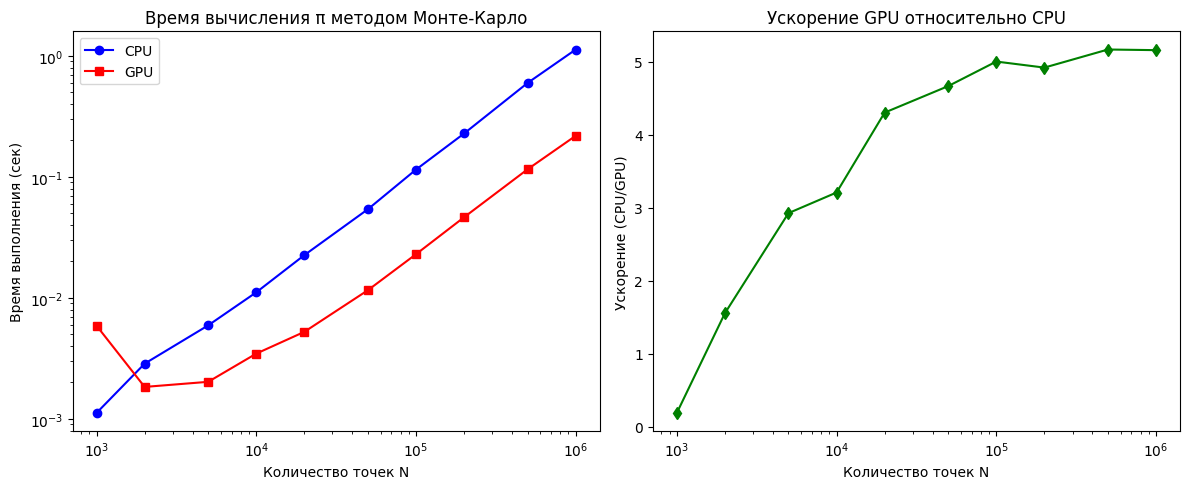

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График времени выполнения
ax1.plot(Ns, cpu_times, 'o-', label='CPU', color='blue')
ax1.plot(Ns, gpu_times, 's-', label='GPU', color='red')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Количество точек N')
ax1.set_ylabel('Время выполнения (сек)')
ax1.set_title('Время вычисления π методом Монте-Карло')
ax1.legend()

# График ускорения
ax2.plot(Ns, speedups, 'd-', color='green')
ax2.set_xscale('log')
ax2.set_xlabel('Количество точек N')
ax2.set_ylabel('Ускорение (CPU/GPU)')
ax2.set_title('Ускорение GPU относительно CPU')
plt.tight_layout()
plt.show()

Было не до конца ясно, можно ли использовать Python, так как в задании про него не сказано, поэтому представлена также реализация на С++:

In [36]:
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpmnhjm8sz".


In [42]:
%%cuda
#include <iostream>
#include <cuda_runtime.h>
#include <curand_kernel.h>
#include <chrono>
#include <fstream>
#include <iomanip>

// CPU версия
double monte_carlo_cpu(unsigned long long int N) {
    unsigned long long int count = 0;
    for (unsigned long long int i = 0; i < N; i++) {
        double x = (double)rand() / RAND_MAX;
        double y = (double)rand() / RAND_MAX;
        if (x*x + y*y <= 1.0) {
            count++;
        }
    }
    return 4.0 * count / N;
}

// CUDA Kernel
__global__ void monte_carlo_gpu_kernel(unsigned long long int N, unsigned long long int* d_count) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = gridDim.x * blockDim.x;

    curandState state;
    curand_init(clock64(), idx, 0, &state);

    unsigned long long int local_count = 0;

    for (unsigned long long int i = idx; i < N; i += stride) {
        float x = curand_uniform(&state);
        float y = curand_uniform(&state);
        if (x*x + y*y <= 1.0f) {
            local_count++;
        }
    }

    atomicAdd(d_count, local_count);
}

// GPU обёртка
double monte_carlo_gpu(unsigned long long int N, double& elapsed_time) {
    unsigned long long int *d_count;
    cudaMalloc(&d_count, sizeof(unsigned long long int));
    cudaMemset(d_count, 0, sizeof(unsigned long long int));

    int threads_per_block = 256;
    int blocks_per_grid = (N + threads_per_block - 1) / threads_per_block;
    if (blocks_per_grid > 1024) blocks_per_grid = 1024;

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    cudaEventRecord(start);

    monte_carlo_gpu_kernel<<<blocks_per_grid, threads_per_block>>>(N, d_count);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);
    elapsed_time = milliseconds / 1000.0;

    unsigned long long int count;
    cudaMemcpy(&count, d_count, sizeof(unsigned long long int), cudaMemcpyDeviceToHost);

    cudaFree(d_count);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    return 4.0 * count / N;
}

int main() {
    unsigned long long int N_values[] = {1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000};
    int num_tests = sizeof(N_values) / sizeof(N_values[0]);

    // Открываем CSV файл для записи результатов
    std::ofstream csv_file("results.csv");
    csv_file << "N,time_cpu,time_gpu,speedup\n";  // заголовок

    std::cout << "---------------------------------------------------------------------------------------------------------" << std::endl;
    std::cout << "N\t\tCPU Pi\t\tCPU Time (s)\tGPU Pi\t\tGPU Time (s)\tSpeedup" << std::endl;
    std::cout << "---------------------------------------------------------------------------------------------------------" << std::endl;

    for (int i = 0; i < num_tests; i++) {
        unsigned long long int N = N_values[i];
        double pi_cpu, pi_gpu, time_cpu, time_gpu;

        auto start_cpu = std::chrono::high_resolution_clock::now();
        pi_cpu = monte_carlo_cpu(N);
        auto end_cpu = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double> elapsed_cpu = end_cpu - start_cpu;
        time_cpu = elapsed_cpu.count();

        pi_gpu = monte_carlo_gpu(N, time_gpu);
        double speedup = time_cpu / time_gpu;

        // Вывод в консоль
        printf("%llu\t\t%.6f\t\t%.4f\t\t%.6f\t\t%.4f\t\t%.2f\n", N, pi_cpu, time_cpu, pi_gpu, time_gpu, speedup);

        // Запись в CSV
        csv_file << N << "," << time_cpu << "," << time_gpu << "," << speedup << "\n";
    }
    std::cout << "--------------------------------------------------------------------------------------------------------" << std::endl;
    csv_file.close();

    std::cout << "\nРезультаты сохранены в 'results.csv'" << std::endl;
    return 0;
}

---------------------------------------------------------------------------------------------------------
N		CPU Pi		CPU Time (s)	GPU Pi		GPU Time (s)	Speedup
---------------------------------------------------------------------------------------------------------
1000		3.132000		0.0000		3.120000		0.0044		0.01
5000		3.173600		0.0002		3.137600		0.0003		0.82
10000		3.151200		0.0004		3.088000		0.0003		1.32
50000		3.136800		0.0018		3.142560		0.0013		1.45
100000		3.140840		0.0037		3.149800		0.0024		1.54
500000		3.141288		0.0210		3.140112		0.0067		3.16
1000000		3.142416		0.0390		3.141196		0.0068		5.75
5000000		3.140870		0.1744		3.141090		0.0066		26.38
10000000		3.141570		0.3545		3.141792		0.0067		53.05
--------------------------------------------------------------------------------------------------------

Результаты сохранены в 'results.csv'



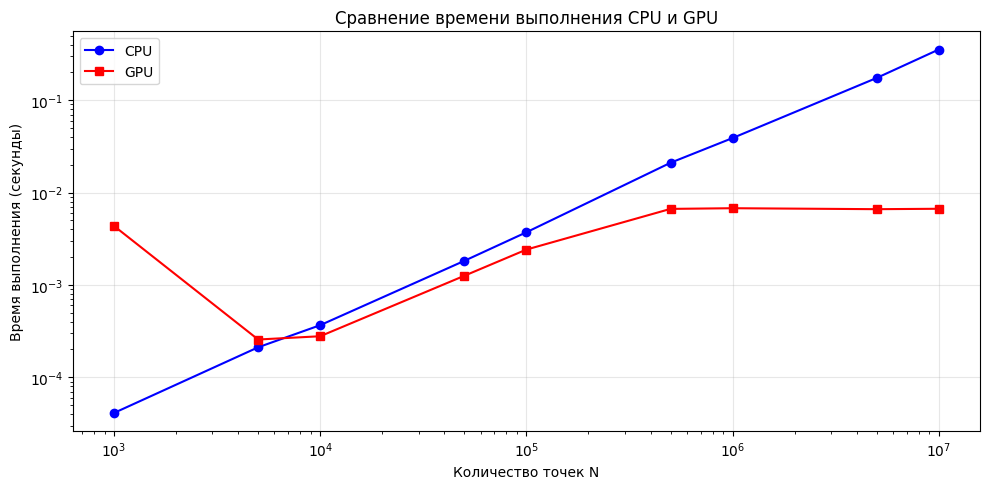

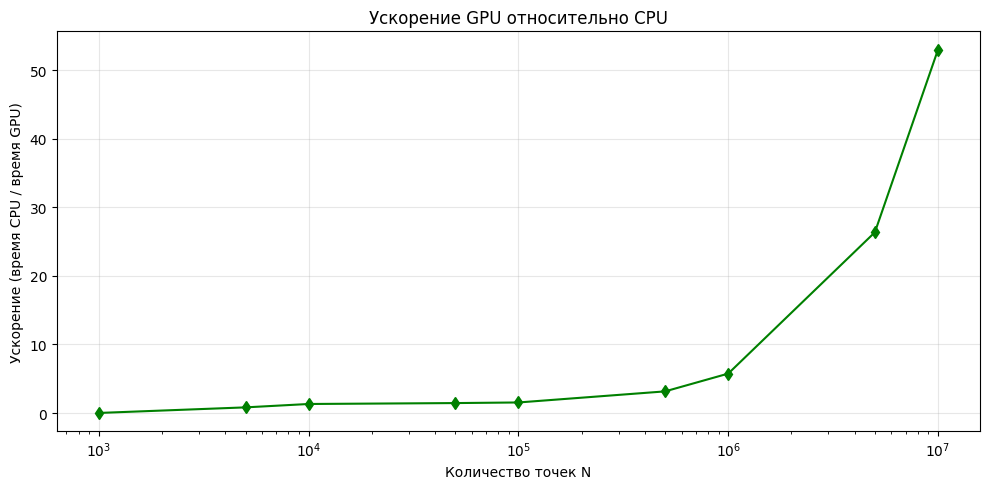


Итоговая таблица:
          N  time_cpu  time_gpu  speedup
0      1000    0.0000    0.0044   0.0094
1      5000    0.0002    0.0003   0.8235
2     10000    0.0004    0.0003   1.3176
3     50000    0.0018    0.0013   1.4511
4    100000    0.0037    0.0024   1.5399
5    500000    0.0210    0.0067   3.1578
6   1000000    0.0390    0.0068   5.7538
7   5000000    0.1744    0.0066  26.3759
8  10000000    0.3545    0.0067  53.0491


In [43]:
# Читаем CSV файл, созданный C++ программой
df = pd.read_csv('results.csv')

# График времени выполнения (CPU и GPU)
plt.figure(figsize=(10, 5))
plt.plot(df['N'], df['time_cpu'], 'o-', label='CPU', color='blue')
plt.plot(df['N'], df['time_gpu'], 's-', label='GPU', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Количество точек N')
plt.ylabel('Время выполнения (секунды)')
plt.title('Сравнение времени выполнения CPU и GPU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График ускорения (GPU/CPU)
plt.figure(figsize=(10, 5))
plt.plot(df['N'], df['speedup'], 'd-', color='green')
plt.xscale('log')
plt.xlabel('Количество точек N')
plt.ylabel('Ускорение (время CPU / время GPU)')
plt.title('Ускорение GPU относительно CPU')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительно: выведем таблицу для справки
print("\nИтоговая таблица:")
print(df.round(4))